In [1]:
import pandas as pd 
import ast 
import nltk
#Para poder delimitar las oraciones y despues tokenizar
nltk.download("punkt_tab")
#Para identificar las puntuaciones 
import string
import numpy as np
#Para aplicar lematizacion y stopwords
import spacy 
#Para tratar los tildes 
import unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer
import plotly.express as px
import matplotlib.pyplot as plt


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\pokem\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
df = pd.read_csv("ted_talks_es.csv")
df.head()

,talk_id,title,speaker_1,all_speakers,occupations,about_speakers,views,recorded_date,published_date,event,native_lang,available_lang,comments,duration,topics,related_talks,url,description,transcript
0,1,Al Gore sobre cómo evitar la crisis climática,Al Gore,{0: 'Al Gore'},{0: ['climate advocate']},{0: 'Nobel Laureate Al Gore focused the world’...,3523396,2006-02-25,2006-06-27,TED2006,en,"['ar', 'bg', 'cs', 'de', 'el', 'en', 'es', 'fa...",272.0,977,"['alternative energy', 'cars', 'climate change...","{243: 'New thinking on the climate crisis', 54...",https://www.ted.com/talks/al_gore_averting_the...,Con el mismo humor y humanidad que irradió en ...,Muchas gracias Chris. Y es en verdad un gran h...
1,7,"David Pogue dice ""La Simplicidad Vende""",David Pogue,{0: 'David Pogue'},{0: ['technology columnist']},{0: 'David Pogue is the personal technology co...,1920803,2006-02-24,2006-06-27,TED2006,en,"['ar', 'bg', 'de', 'el', 'en', 'es', 'fa', 'fr...",124.0,1286,"['computers', 'entertainment', 'interface desi...","{1725: '10 top time-saving tech tips', 2274: '...",https://www.ted.com/talks/david_pogue_simplici...,"El columnista del New York Times, David Pogue,...","Hola contestadora automática, mi vieja amiga. ..."
2,53,Un recorrido por la renovación urbana de la ma...,Majora Carter,{0: 'Majora Carter'},{0: ['activist for environmental justice']},{0: 'Majora Carter redefined the field of envi...,2664029,2006-02-26,2006-06-27,TED2006,en,"['ar', 'bg', 'bn', 'ca', 'cs', 'de', 'en', 'es...",219.0,1116,"['MacArthur grant', 'activism', 'business', 'c...",{1041: '3 stories of local eco-entrepreneurshi...,https://www.ted.com/talks/majora_carter_greeni...,"En una charla altamente emotiva, la activista ...","Si están presentes aquí hoy, y estoy muy conte..."
3,66,Ken Robinson dice que las escuelas matan la cr...,Sir Ken Robinson,{0: 'Sir Ken Robinson'},"{0: ['author', 'educator']}","{0: ""Creativity expert Sir Ken Robinson challe...",65052534,2006-02-25,2006-06-27,TED2006,en,"['af', 'ar', 'az', 'be', 'bg', 'bn', 'ca', 'cs...",4931.0,1164,"['children', 'creativity', 'culture', 'dance',...","{865: 'Bring on the learning revolution!', 173...",https://www.ted.com/talks/sir_ken_robinson_do_...,Sir Ken Robinson plantea de manera entretenida...,"Buenos días. ¿Cómo están? Ha sido increíble, ¿..."
4,92,Hans Rosling nos muestra las mejores estadísti...,Hans Rosling,{0: 'Hans Rosling'},{0: ['global health expert; data visionary']},"{0: 'In Hans Rosling’s hands, data sings. Glob...",14501766,2006-02-22,2006-06-27,TED2006,en,"['ar', 'az', 'bg', 'bn', 'bs', 'cs', 'da', 'de...",628.0,1190,"['Africa', 'Asia', 'Google', 'demo', 'economic...","{2056: ""Own your body's data"", 2296: 'A visual...",https://www.ted.com/talks/hans_rosling_the_bes...,Una manera única de presentar datos. Con la en...,"Hace unos 10 años, emprendí la tarea de enseña..."


In [3]:
##Es un string ,necesitmaos que sea una lista para usar explode
type(df.topics[0])

str

In [4]:
### Citar de donde saque para usar literal eval 
### https://stackoverflow.com/questions/1894269/how-to-convert-string-representation-of-list-to-a-list

In [5]:
##Transformamos de string a lista
df["topics"] = df.topics.apply(lambda x : ast.literal_eval(x))

In [6]:
df.topics

0       [alternative energy, cars, climate change, cul...
1       [computers, entertainment, interface design, m...
2       [MacArthur grant, activism, business, cities, ...
3       [children, creativity, culture, dance, educati...
4       [Africa, Asia, Google, demo, economics, global...
                              ...                        
3916    [life, society, immigration, humanity, self, p...
3917    [TED-Ed, education, animation, fashion, climat...
3918    [life, emotions, communication, stigma, psycho...
3919    [coronavirus, pandemic, epidemiology, virus, b...
3920    [TED-Ed, education, history, animation, intell...
Name: topics, Length: 3921, dtype: object

In [7]:
#Expande la lista y crea una fila por topico
explode  = df.explode("topics")
explode.head(4)

,talk_id,title,speaker_1,all_speakers,occupations,about_speakers,views,recorded_date,published_date,event,native_lang,available_lang,comments,duration,topics,related_talks,url,description,transcript
0,1,Al Gore sobre cómo evitar la crisis climática,Al Gore,{0: 'Al Gore'},{0: ['climate advocate']},{0: 'Nobel Laureate Al Gore focused the world’...,3523396,2006-02-25,2006-06-27,TED2006,en,"['ar', 'bg', 'cs', 'de', 'el', 'en', 'es', 'fa...",272.0,977,alternative energy,"{243: 'New thinking on the climate crisis', 54...",https://www.ted.com/talks/al_gore_averting_the...,Con el mismo humor y humanidad que irradió en ...,Muchas gracias Chris. Y es en verdad un gran h...
0,1,Al Gore sobre cómo evitar la crisis climática,Al Gore,{0: 'Al Gore'},{0: ['climate advocate']},{0: 'Nobel Laureate Al Gore focused the world’...,3523396,2006-02-25,2006-06-27,TED2006,en,"['ar', 'bg', 'cs', 'de', 'el', 'en', 'es', 'fa...",272.0,977,cars,"{243: 'New thinking on the climate crisis', 54...",https://www.ted.com/talks/al_gore_averting_the...,Con el mismo humor y humanidad que irradió en ...,Muchas gracias Chris. Y es en verdad un gran h...
0,1,Al Gore sobre cómo evitar la crisis climática,Al Gore,{0: 'Al Gore'},{0: ['climate advocate']},{0: 'Nobel Laureate Al Gore focused the world’...,3523396,2006-02-25,2006-06-27,TED2006,en,"['ar', 'bg', 'cs', 'de', 'el', 'en', 'es', 'fa...",272.0,977,climate change,"{243: 'New thinking on the climate crisis', 54...",https://www.ted.com/talks/al_gore_averting_the...,Con el mismo humor y humanidad que irradió en ...,Muchas gracias Chris. Y es en verdad un gran h...
0,1,Al Gore sobre cómo evitar la crisis climática,Al Gore,{0: 'Al Gore'},{0: ['climate advocate']},{0: 'Nobel Laureate Al Gore focused the world’...,3523396,2006-02-25,2006-06-27,TED2006,en,"['ar', 'bg', 'cs', 'de', 'el', 'en', 'es', 'fa...",272.0,977,culture,"{243: 'New thinking on the climate crisis', 54...",https://www.ted.com/talks/al_gore_averting_the...,Con el mismo humor y humanidad que irradió en ...,Muchas gracias Chris. Y es en verdad un gran h...


In [8]:
#Los topicos que hay 
#topicos = list(explode.topics.unique())
#for x in topicos : 
    #print(x)

Elegimos el Tema de nuestro corpus de charlas TED solo las que Hablan de IA ya que es un tema interesante para nosotros el como se explica el tema de la IA de cara al publico. De esta forma podremos ver cuales palabras son mas repetidas o representativas en torno a charlas para el publico comun y corriente y si giran en torno a algun subtema en especifico o no. La cantidad de charlas con este tema son 74 (ver codigo 2 celdas mas abajo).

En torno a nuestra hipotesis inicial acerca de que esperariamos encontrar en este corpus, creemos que es probable que encontremos palabras relacionadas con la etica, la creatividad o que hablen del futuro entre la IA y la humanidad. Esto lo creemos debido al sesgo que suele tener el publico y nuestra expectativa de los temas que suelen tratar las charlas que giran en torno a IA de cara al publico

In [9]:
#Necesitamos saber el tema que va a tratr y seleccionar aquellos temas que se relacionan
#Seleccionamos todas las charlas que hablan de inteligencia artificial. 
AI = explode[explode.topics == "AI"]
AI

,talk_id,title,speaker_1,all_speakers,occupations,about_speakers,views,recorded_date,published_date,event,native_lang,available_lang,comments,duration,topics,related_talks,url,description,transcript
104,125,"Jeff Hawkins en ""Cómo la ciencia del cerebro c...",Jeff Hawkins,{0: 'Jeff Hawkins'},"{0: ['computer designer', 'brain researcher']}","{0: ""Jeff Hawkins pioneered the development of...",1683289,2003-02-02,2007-05-21,TED2003,en,"['ar', 'bg', 'da', 'de', 'el', 'en', 'es', 'fa...",244.0,1211,AI,"{184: '3 clues to understanding your brain', 2...",https://www.ted.com/talks/jeff_hawkins_how_bra...,"Creador del Treo, Jeff Hawkins, nos anima a ve...","Yo hago dos cosas, diseño computadora móviles ..."
147,165,"Hod Lipson construye robots ""autoconscientes""",Hod Lipson,{0: 'Hod Lipson'},{0: ['roboticist']},{0: 'Hod Lipson works at the intersection of e...,1465747,2007-03-06,2007-10-11,TED2007,en,"['ar', 'bg', 'cs', 'de', 'el', 'en', 'es', 'fa...",242.0,378,AI,"{195: 'The sticky wonder of gecko feet', 146: ...",https://www.ted.com/talks/hod_lipson_building_...,Hod Lipson muestra unos cuantos de sus pequeño...,"Entonces, ¿dónde están los robots? Nos han dic..."
295,355,Rodney Brooks dice que los robots invadirán nu...,Rodney Brooks,{0: 'Rodney Brooks'},{0: ['roboticist']},{0: 'Rodney Brooks builds robots based on biol...,692492,2003-02-02,2008-09-29,TED2003,en,"['ar', 'bg', 'cs', 'en', 'es', 'fr', 'he', 'it...",85.0,1127,AI,"{195: 'The sticky wonder of gecko feet', 165: ...",https://www.ted.com/talks/rodney_brooks_robots...,"En esta charla profética, del 2003, el experto...",De lo que quiero hablarles hoy es de cómo veo ...
628,820,Dennis Hong: Mis siete especies de robots.,Dennis Hong,{0: 'Dennis Hong'},{0: ['roboticist']},{0: 'Dennis Hong is the founder and director o...,2248065,2009-09-10,2010-04-07,TEDxNASA,en,"['ar', 'bg', 'cs', 'de', 'el', 'en', 'es', 'fa...",189.0,955,AI,{280: 'Robots inspired by cockroach ingenuity'...,https://www.ted.com/talks/dennis_hong_my_seven...,"En TEDxNASA, Dennis Hong presenta siete robots...",El primer robot del que voy a hablar se llama ...
709,932,"Peter Molyneux hace una demostración de Milo, ...",Peter Molyneux,{0: 'Peter Molyneux'},{0: ['game changer']},{0: 'The head of Microsoft\'s European games d...,854065,2010-07-09,2010-08-18,TEDGlobal 2010,en,"['ar', 'bg', 'cs', 'de', 'el', 'en', 'es', 'fa...",211.0,655,AI,"{799: 'Gaming can make a better world', 816: '...",https://www.ted.com/talks/peter_molyneux_meet_...,"Peter Molyneux hace una demostración de Milo, ...","Cuando vi una tecnología denominada Kinect, se..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3654,49131,El peligro de la IA es más extraño de lo que p...,Janelle Shane,{0: 'Janelle Shane'},{0: ['ai researcher']},{0: 'While moonlighting as a research scientis...,406152,2019-04-15,2019-10-22,TED2019,en,"['ar', 'cs', 'en', 'es', 'fa', 'fr', 'he', 'hu...",26.0,628,AI,"{36479: 'How to keep human bias out of AI', 40...",https://www.ted.com/talks/janelle_shane_the_da...,El peligro de la inteligencia artificial no es...,La inteligencia artificial es conocida por tra...
3658,50986,"El mito griego de Talos, el primer robot",Adrienne Mayor,{0: 'Adrienne Mayor'},NaN,NaN,1261885,2019-10-24,2019-10-24,TED-Ed,en,"['ar', 'de', 'el', 'en', 'es', 'fa', 'fr', 'he...",NaN,223,AI,{46592: 'The myth of Jason and the Argonauts '...,https://www.ted.com/talks/adrienne_mayor_the_g...,Mira la lección completa en https://ed.ted.com...,"Hefesto, el dios de la tecnología, se encontra..."
3663,50637,El potencial médico de la IA y los metabolitos,Leila Pirhaji,{0: 'Leila Pirhaji'},{0: ['biotech entrepreneur']},{0: 'Leila Pirhaji uses artificial intelligenc...,1396187,2019-04-15,2019-10-29,TED2019,en,"['ar', 'cs', 'de', 'en', 'es', 'fa', 'fr', 'gu...",7.0,314,AI,{20008: 'How AI is making it easier to diagnos...,https://www.ted.com/talks/leila_pirhaji_the_me...,Muchas enfermedades son causadas por metabolit...,"En 2003, cuando se

In [10]:
### NANDO = [1,2,5,6]
#YO = [3,4,7]
#JUNTO = [8,9]

In [11]:
#MUESTRA DE COMO ES EL TEXTO DE UNA CHARLA solo primeros 1000 caracteres
AI.transcript.iloc[0][0:1000]

'Yo hago dos cosas, diseño computadora móviles y estudio cerebros. Y la charla de hoy se trata de cerebros y, ¡Si! En algún lugar tengo un fan de cerebros. (Risas) Voy a, si me pueden poner la primera diapositiva, y verán el titulo de mi platica y mis dos afiliaciones. Así que de lo que voy a hablar, es el porqué no tenemos una buena teoría acerca del cerebro, porque es importante que desarrollemos una y qué podemos hacer al respecto. Intentaré hacer eso en 20 minutos. Tengo dos afiliaciones. La mayoría de ustedes me conocen por mis días de Palm y Handspring pero también administro un instituto de investigación científica sin fines de lucro. llamado el Instituto Redwood de Neurociencia en Menlo Park, y estudiamos neurociencia teórica, y estudiamos como funciona la neo-corteza. Voy a hablar acerca de todo eso. Tengo sólo una diapositiva sobre mi otra vida, las computadoras, y es ésta. Estos son algunos de los productos que desarrollé en los últimos 20 años, empezando desde la muy origin

In [12]:
##Todos las charlas 
charlas = list(AI.transcript)
titulos = [x for x in AI.title]
#CANTIDAD DE CHARLAS A PROCESAR
len(charlas)

74

## Preprocesamiento de texto

In [13]:
#tokenizacion 
#Tokenizo cada charla
tokenization = [nltk.word_tokenize(charla) for charla in charlas]
tokenization[0][0:6]

['Yo', 'hago', 'dos', 'cosas', ',', 'diseño']

### Saqué la informacion desde https://www.geeksforgeeks.org/python/how-to-remove-string-accents-using-python-3/

In [14]:
def quitar_tildes(texto): 
   # Normalizamos el texto
    normalizado= unicodedata.normalize('NFKD', texto)  
    
    final = ''.join([letra for letra in normalizado if not unicodedata.combining(letra)])  
    return final 

In [15]:
#https://www.geeksforgeeks.org/nlp/stop-words-using-spacy/   
#para usar stopwords


In [16]:
#Parte limpieza de stopwords,puntuacion ,tildes y signos de interrogacion
limpio = []
nlp =spacy.load("es_core_news_sm")
stopword = nlp.Defaults.stop_words
puntuacion = string.punctuation 

for charla in tokenization : 
    #Por cada charla revisamos si sus token tienen stopwords o puntuacion
    #Eliminamos signos de interrogacion(¿?) que estaban pegados a las palabras
    charla_limpia =[]
    for palabra in charla : 
        palabra_limpia = ""
        if palabra.lower() not in stopword and palabra not in puntuacion:
            for letra in palabra : 
                #puntuacion no tiene "¡" asi que lo agrego manual
                if letra not in puntuacion and letra != "¡" and not letra.isdigit() :
                    palabra_limpia+=letra
            #Aqui termina de procesar palabra 
            #Quito los tildes y añado en minunscula 
            palabra_limpia = quitar_tildes(palabra_limpia)
            #Chequeo si despues de las tides sigue siendo valida
            if palabra_limpia.lower() not in stopword: 
                charla_limpia.append(palabra_limpia.lower())
    limpio.append(charla_limpia)
    


In [17]:
limpio[0][0:6]

['cosas', 'diseno', 'computadora', 'moviles', 'estudio', 'cerebros']

## La informacion para aplicar lematizacion a codigo la sequé de : https://localhorse.net/article/como-lematizar-en-python 

## Para que se pueda ejecutar se debe descargar la libreria de spacy y se debe ejecutar "python -m spacy download es_core_news_sm" en la terminal  en la ruta donde se tenga a python

# Ademas de https://stackoverflow.com/questions/62268302/spacy-es-core-news-sm-model-not-loading para solucionar error de importacion 

In [18]:
#Aplico lematizacion para reducir tamaño de matriz,lo que hace es que reduce la palabra a su forma base y asegura que sea válida
modelo = spacy.load("es_core_news_sm")
charla_final = []

for charla in limpio :

    #Me pide string asi que junto todo 
    charla_unida = " ".join(charla)
    doc = modelo(charla_unida)
    lematizado =[token.lemma_ for token in doc]
    charla_final.append(lematizado)

    
    

# Para la aplicacion de quitar terminos no relevante sy los metodos de TfidfVectorizer la saqué de :https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

In [19]:
#Aplicamos TfidfVectorizer ,dejo las palabras que aparezcan en al menos 3 charlas
tfid = TfidfVectorizer(min_df=3)
#Como tfid acepta solo string ,unimos charlas
charlas_unidas =[" ".join(charla) for charla in charla_final]
tfid_matriz = tfid.fit_transform(charlas_unidas)

In [20]:
#Cada fila es una documento  (reporte vocabulario final)
tfid_matriz

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 24662 stored elements and shape (74, 2842)>

In [21]:
#Cantidad de palabras unicas final (vocabulario)
len(tfid.vocabulary_)

2842

# El preprocesamiento es valido ,ya que primero ,reducimos tamaño ,dejando todo en minuscula,eliminamos las tildes para que no hayan problemas con que a algunas palabras no le pusieron y que otras si ,entonces se nos generen mas columnas innecesariamente, ademas eliminamos signos de puntuacion y stopwords.Ademas dejamos las palabras que se repiten en al menos 3 charlas ,para eliminar las demas que son raras y así eliminamos ruido

In [22]:
#Transponemos la matriz para seguir normativa del curso,donde los documentosson las columnas y los terminos son las filas
matriz_final = tfid_matriz.T

# 4. Construir matriz textual 

In [23]:
#Mostramos como se organiza la matriz
df = pd.DataFrame(matriz_final.toarray(), index=tfid.get_feature_names_out())
df

,0,1,2,3,4,5,6,7,8,9,...,64,65,66,67,68,69,70,71,72,73
abajo,0.000000,0.000000,0.051410,0.000000,0.000000,0.000000,0.000000,0.031902,0.000000,0.021278,...,0.028137,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
abandonar,0.000000,0.053673,0.053351,0.000000,0.000000,0.000000,0.000000,0.016553,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.031380,0.0,0.0,0.000000,0.000000
abierto,0.000000,0.000000,0.000000,0.019338,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.068343,0.000000
abogado,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.037940,0.000000,0.0,0.0,0.000000,0.000000
abordamos,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020096,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
yo,0.008034,0.000000,0.000000,0.012129,0.021688,0.031531,0.011861,0.000000,0.000000,0.000000,...,0.030298,0.000000,0.063580,0.000000,0.037807,0.000000,0.0,0.0,0.021432,0.000000
york,0.000000,0.000000,0.000000,0.000000,0.000000,0.060777,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
youtube,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.037940,0.032674,0.0,0.0,0.000000,0.000000
zona,0.000000,0.000000,0.000000,0.026772,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000


# Dimension de la matriz 

In [24]:
df.shape

(2842, 74)

## La matriz fue construida desde el proceso donde aplicamos TfidfVectorizer,donde lo que hace es darle un peso a cada valor,seugun su frecuencia y las penaliza si son muy frecuentes

# La entrada $A_{ij}$ representa que tan importante es la palabra i en la charla j

# 5. Calculo SVD


In [25]:
MF = matriz_final.toarray()

U, s, VT = np.linalg.svd(MF, full_matrices = False)
Sigma = np.diag(s)
print ("Forma U:", U.shape)
print("Forma Sigma:" ,Sigma.shape)
print("Forma VT:" ,VT.shape)

Forma U: (2842, 74)
Forma Sigma: (74, 74)
Forma VT: (74, 74)


In [26]:
#verificamos reconstruccion 
matriz_reconstruida = U @ Sigma @ VT
print("error de construccion:", np.linalg.norm(MF - matriz_reconstruida))

error de construccion: 2.6606134568928973e-14


El error de reconstrucción obtenido es del orden de 10e-14 lo cual es prácticamente cero. Esto confirma que la descomposición en valores singulares se ha calculado correctamente y permite reconstruir la matriz original sin pérdida significativa de información.


# 6. Analisis de Valores Singulares


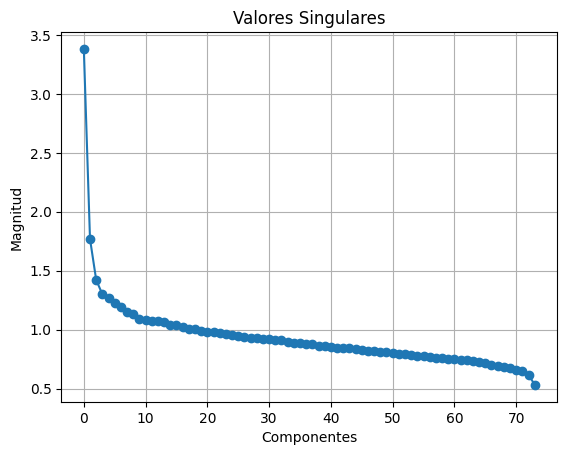

In [27]:
plt.figure()
plt.plot(s, "o-")
plt.title("Valores Singulares")
plt.xlabel("Componentes")
plt.ylabel("Magnitud")
plt.grid(True)
plt.show()

Se observa una gran caida entre 1 tema en especifico y luego otra caida mas pequeña antes de que el grafico sea mas suave, es por esto que se puede decir que hay 1 tema muy predominante seguido de unos 2 temas mas relevantes y repetidos que el resto

Valores singulares representan la importancia de los componentes del corpus, en este caso a los temas mas dominantes.
Los izquierdos (U) tema expresado en palabras, mientras que los derechos (V) representan la direccion en el espacio de documentos, en nuestro caso como cada documento se relaciona con los temas que tenemos y mostrando que tanta asociacion tiene una charla y sus componentes

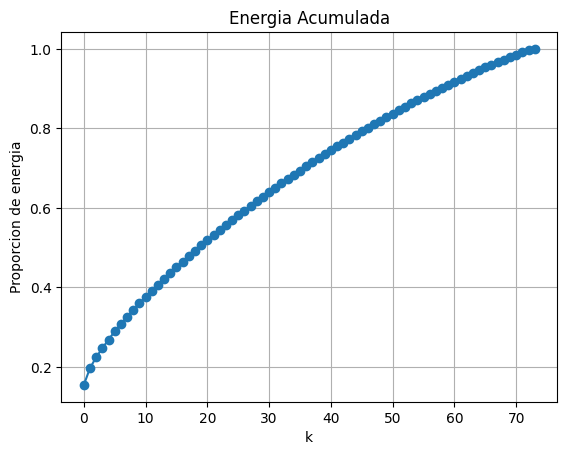

In [28]:
energia = s**2
ener_acum = np.cumsum(energia)/np.sum(energia)
plt.figure()
plt.plot(ener_acum, "o-")
plt.title("Energia Acumulada")
plt.xlabel("k")
plt.ylabel("Proporcion de energia")
plt.grid(True)
plt.show()

          

In [29]:
#Dado que la mayor parte de nuestra energia se concentra en alrededor de k = 50 , aprox 80% asi presrvamos los valores mas importantes sin 
#perder info relevante, usaremos el k=50 ya que segun el grafico es cercano al 80% de energia. Lo mas importante de esto es que reducimos la dimensionalidad
k = 50
U_k = U[:, :k]
Sigma_k = Sigma[:k, :k]
VT_k = VT[:k, :]

Matriz_simplificada = U_k @ Sigma_k @ VT_k #matriz simplificada por temas al elegir el k=50 luego del grafico


# 7 Componentes mas importantes

In [30]:
#Documentos 
D_50 = Sigma_k @ VT_k
D_50

array([[-0.42812016, -0.40715755, -0.47435649, ..., -0.19671891,
        -0.30922735, -0.32700968],
       [ 0.06643855, -0.37539952, -0.68707337, ...,  0.07343372,
         0.08794855,  0.09032629],
       [-0.18085929,  0.03445593,  0.00347547, ..., -0.11308974,
        -0.09726611, -0.03329669],
       ...,
       [ 0.03589128,  0.10118023,  0.01696837, ...,  0.02474771,
         0.03273101, -0.02833356],
       [ 0.03606462,  0.08584962, -0.00695984, ...,  0.10909606,
         0.05517053,  0.03165138],
       [ 0.08185777,  0.11667214, -0.00855709, ...,  0.18247254,
        -0.12246787, -0.00424721]], shape=(50, 74))

In [31]:
#Terminos 
T_50 = U_k @ Sigma_k
T_50

array([[-3.05610948e-02, -2.11246767e-02, -1.06693138e-02, ...,
         6.29637259e-04, -5.12973779e-03, -1.72312487e-03],
       [-3.39180560e-02, -2.44236080e-02,  2.69740096e-03, ...,
         3.98215096e-03,  1.43091451e-02,  2.55299819e-02],
       [-5.56233286e-02,  1.66169869e-02, -4.43837021e-02, ...,
         6.23785050e-03, -6.23965499e-03,  9.16599973e-03],
       ...,
       [-5.84989547e-02,  3.01575012e-02, -3.89478858e-02, ...,
         1.94118187e-02, -3.62089109e-03, -4.71150414e-03],
       [-1.78385694e-02, -9.32556650e-03,  4.49059625e-03, ...,
         1.18036343e-02, -1.19745821e-02,  1.17847402e-02],
       [-7.13167984e-01,  1.55805520e-03, -7.32103596e-03, ...,
        -2.41335561e-03, -3.98662135e-02, -2.26212401e-02]],
      shape=(2842, 50))

In [32]:
x_documentos = D_50[0, :]#Todos los documentos ,solo me interesa primera componente (lo que mas info me da)
y_documentos = D_50[1, :]#Todos los documentos ,solo me interesa segunda componente
#Usamos las filas de la matriz ,como indica el enunciado

In [ ]:
fig = px.scatter(x_documentos, y_documentos, titulos, title="Documentos en SVD")
fig.show()

In [1155]:
#Usamos las columnas como dice el enucniado
x_terminos = T_50[:, 0]
y_terminos = T_50[:, 1]  

In [1156]:
significado = tfid.get_feature_names_out()

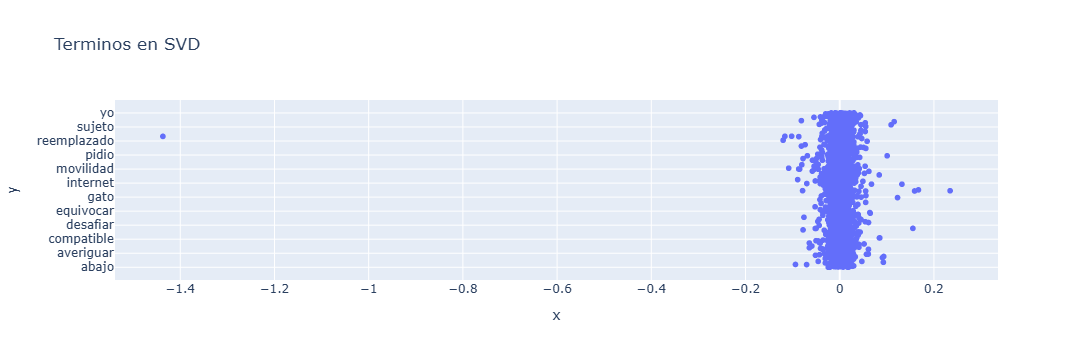

In [1157]:
fig2 = px.scatter(x_terminos, y_terminos, significado, title="Terminos en SVD")
fig2.show()